In [ ]:
#@title 0. Import Frameworks:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


Dataset successfully loaded. Shape: (962, 7)
label
healthy        351
imbalanced     339
obstruction    272
Name: count, dtype: int64
[OK] Đã nạp dữ liệu thành công!

--- Satistical Table ---
             The number of samples (Windows)  Percentage (%)
label                                                       
healthy                                  351       36.486486
imbalanced                               339       35.239085
obstruction                              272       28.274428
--------------------------------------


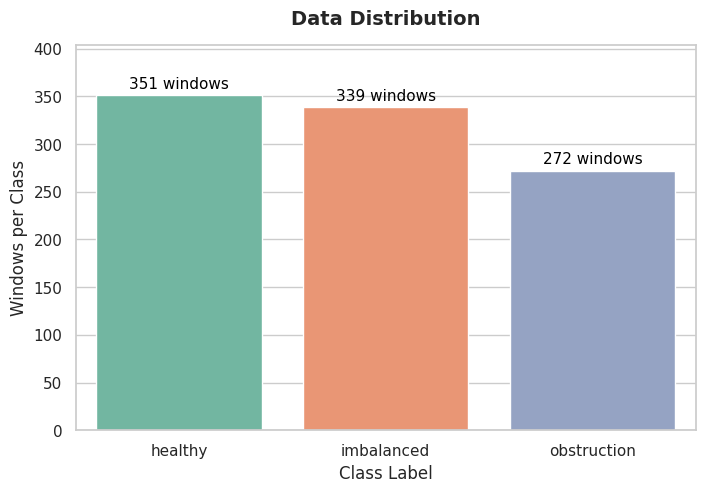

In [ ]:
#@title 1. Read preprocessed file:
# 1. Load the features generated by window.py and FFT_extraction.py
features_file = "features_for_deployment.csv"

if not os.path.exists(features_file):
    raise FileNotFoundError(
        f"Could not find '{features_file}'. Please run FFT_extraction.py first!"
    )

FILE_PATH = "features_for_deployment.csv"

df_master = pd.read_csv(features_file)
print(f"Dataset successfully loaded. Shape: {df_master.shape}")
print(df_master["label"].value_counts())

# 2. Strict alignment with raw_features[6] array order in IIR_deployment_Regression.ino
feature_columns = [
    "RMS_X",
    "RMS_Y",
    "RMS_Z",
    "Band_Power_Z_Low",
    "Band_Power_Z_Mid",
    "Band_Power_Z_High",
]

X = df_master[feature_columns].values
y = df_master["label"].values

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Standard Scaler initialization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

try:
    df = pd.read_csv(FILE_PATH)
    print("[OK] Đã nạp dữ liệu thành công!\n")

    # Count the number of samples, as calculating their percentage:
    class_counts = df['label'].value_counts()
    class_percentages = df['label'].value_counts(normalize=True) * 100

    # A table for illustration:
    summary_df = pd.DataFrame({
        'The number of samples (Windows)': class_counts,
        'Percentage (%)': class_percentages
    })
    print("--- Satistical Table ---")
    print(summary_df.to_string())
    print("-" * 38)

    # Illustrate using bar chart:
    plt.figure(figsize=(8, 5))
    sns.set_theme(style="whitegrid")

    ax = sns.countplot(x='label', data=df, palette='Set2', hue='label', legend=False)

    # Show statistic on the head of each chart:
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())} windows',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline',
                    fontsize=11, color='black',
                    xytext=(0, 5),
                    textcoords='offset points')

    plt.title('Data Distribution', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Class Label', fontsize=12)
    plt.ylabel('Windows per Class', fontsize=12)
    plt.ylim(0, max(class_counts) * 1.15)

    plt.show()

except FileNotFoundError:
    print(f"Unable to find the file!")


Successfully imported data!
Samples: 962


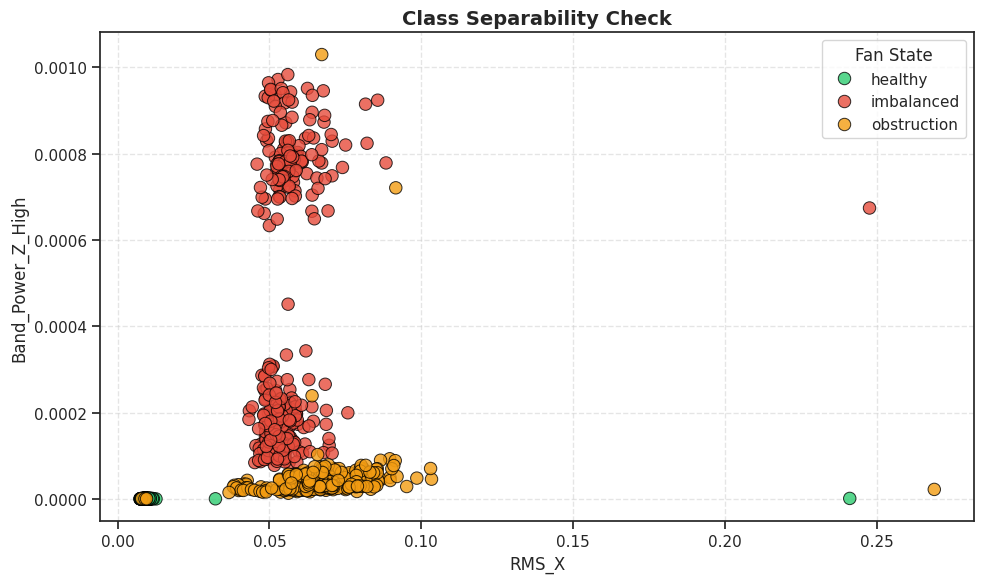

In [ ]:
#@title 2. Scatter Plot

try:
    df = pd.read_csv(FILE_PATH)

    print("Successfully imported data!")
    print(f"Samples: {len(df)}")

    plt.figure(figsize=(10, 6))
    sns.set_theme(style="ticks")

    colors = {
        "healthy": "#2ecc71",
        "imbalanced": "#e74c3c",
        "obstruction": "#f39c12"
    }

    sns.scatterplot(
        data=df,
        x="RMS_X",
        y="Band_Power_Z_High",
        hue="label",
        palette=colors,
        alpha=0.8,
        s=80,
        edgecolor="black"
    )

    plt.title("Class Separability Check", fontsize=14, fontweight="bold")
    plt.xlabel("RMS_X")
    plt.ylabel("Band_Power_Z_High")

    plt.legend(title="Fan State")
    plt.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"File not found: {FILE_PATH}")

except KeyError as e:
    print(f"Missing column: {e}")
    print("Available columns:")
    print(df.columns.tolist())

[OK] Data loaded and time-axis synchronized successfully!



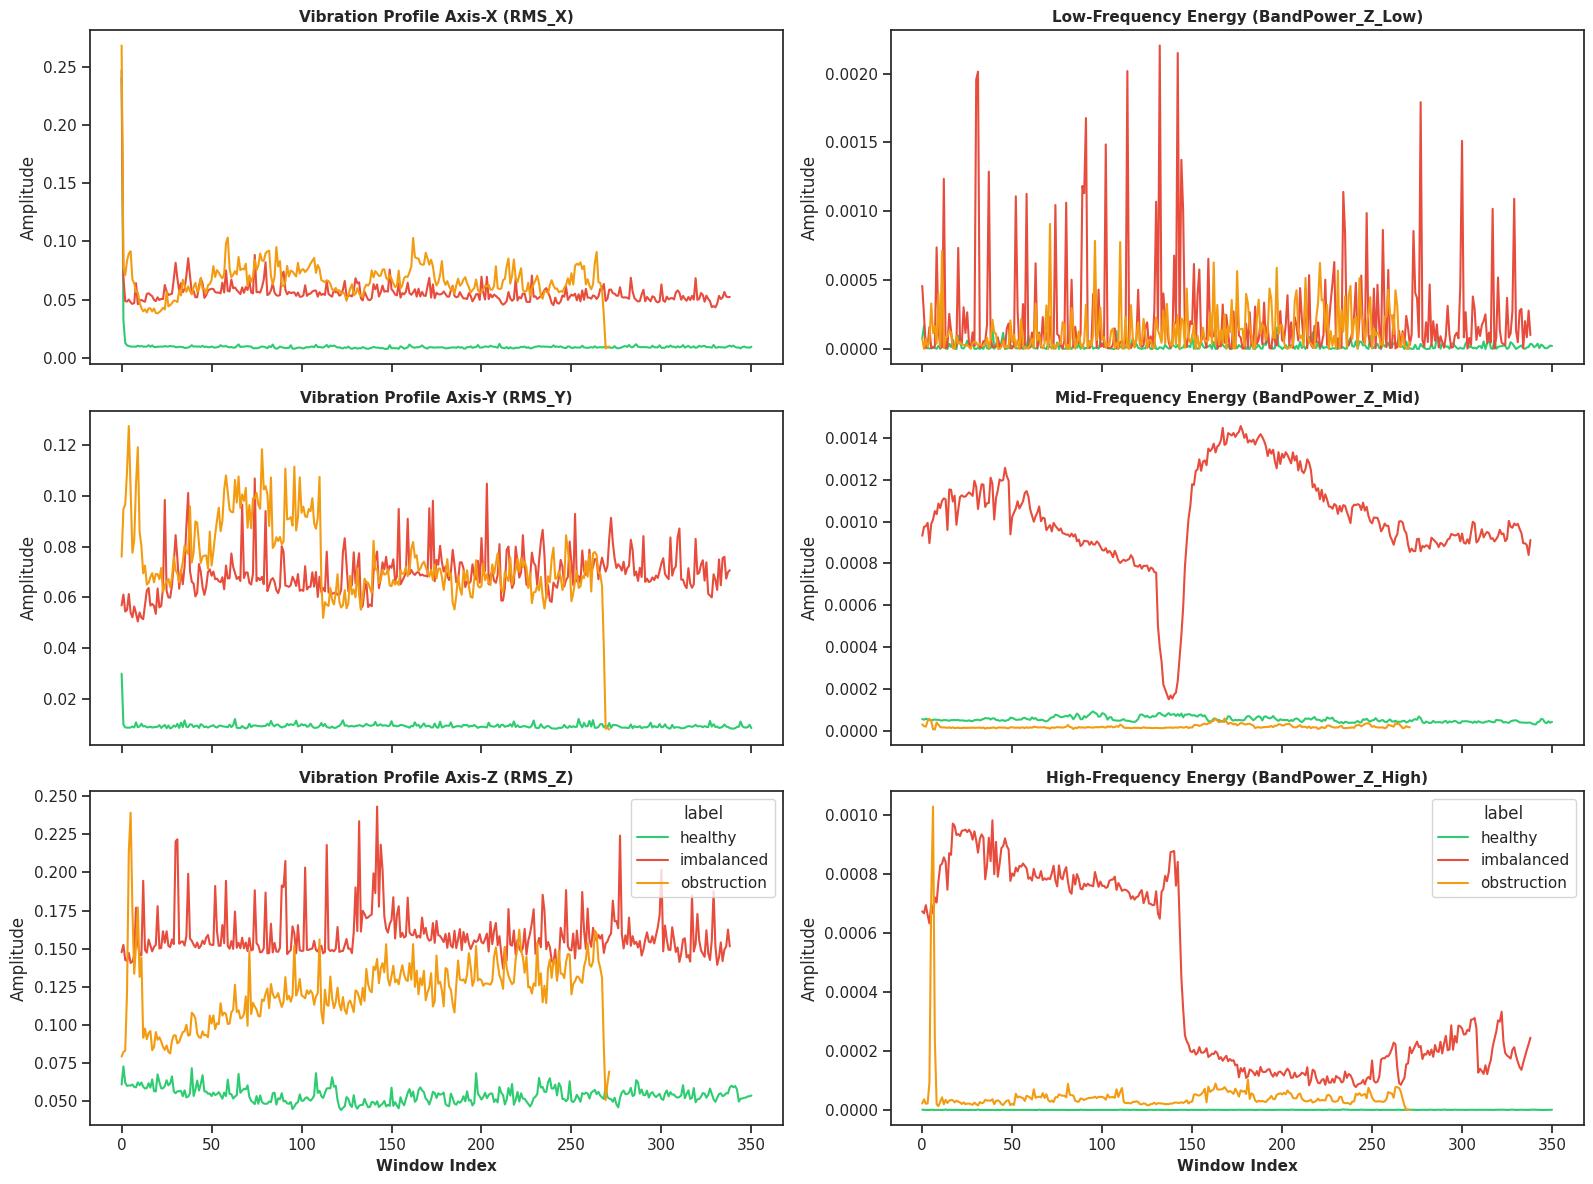

In [ ]:
#@title 3. Feature Verification and Inspection
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    df = pd.read_csv(FILE_PATH)

    # Synchronize time-axis by generating sequential Window Index per Class
    df['Window_Index'] = df.groupby('label').cumcount()
    print("[OK] Data loaded and time-axis synchronized successfully!\n")

    # Initialize Grid Plot: 3 rows (Axes/Bands) x 2 columns (Col 1: RMS, Col 2: BandPower)
    fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharex=True)
    sns.set_theme(style="whitegrid")

    # Monolithic color palette for system-wide consistency
    colors = {"healthy": "#2ecc71", "imbalanced": "#e74c3c", "obstruction": "#f39c12"}

    # Target feature vectors for visualization
    rms_features = ['RMS_X', 'RMS_Y', 'RMS_Z']
    bp_features = ['Band_Power_Z_Low', 'Band_Power_Z_Mid', 'Band_Power_Z_High']

    titles_rms = ['Vibration Profile Axis-X (RMS_X)', 'Vibration Profile Axis-Y (RMS_Y)', 'Vibration Profile Axis-Z (RMS_Z)']
    titles_bp = ['Low-Frequency Energy (BandPower_Z_Low)', 'Mid-Frequency Energy (BandPower_Z_Mid)', 'High-Frequency Energy (BandPower_Z_High)']

    # Execution Loop: Generate 6 distinct subplots
    for i in range(3):
        # Column 1: Time-Domain Features (RMS)
        sns.lineplot(
            data=df, x='Window_Index', y=rms_features[i], hue='label',
            palette=colors, linewidth=1.5, ax=axes[i, 0]
        )
        axes[i, 0].set_title(titles_rms[i], fontsize=11, fontweight='bold')
        axes[i, 0].set_ylabel('Amplitude')
        # Redundant legend suppression to optimize layout visibility
        if i < 2: axes[i, 0].get_legend().remove()

        # Column 2: Frequency-Domain Features (BandPower)
        sns.lineplot(
            data=df, x='Window_Index', y=bp_features[i], hue='label',
            palette=colors, linewidth=1.5, ax=axes[i, 1]
        )
        axes[i, 1].set_title(titles_bp[i], fontsize=11, fontweight='bold')
        axes[i, 1].set_ylabel('Amplitude')
        if i < 2: axes[i, 1].get_legend().remove()

    # Configure X-Axis labels for the terminal plots only (Memory/Visual optimization)
    axes[2, 0].set_xlabel('Window Index', fontsize=11, fontweight='bold')
    axes[2, 1].set_xlabel('Window Index', fontsize=11, fontweight='bold')

    # Optimize padding parameters to prevent text overlap
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"[ERROR] Target file '{FILE_PATH}' missing. Execute the preprocessing pipeline first!")


/tmp/ipykernel_1653/2393034076.py:19: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_data[cls] = pd.read_csv(file_path)


[OK] All continuous RAW data streams loaded successfully!

=== 1. SIGNAL CLIPPING & SATURATION CHECK ===
[HEALTHY] Peak Amplitude -> X: 0.99, Y: 0.13, Z: 0.21 m/s^2
[IMBALANCED] Peak Amplitude -> X: 1.02, Y: 0.29, Z: 0.60 m/s^2
[OBSTRUCTION] Peak Amplitude -> X: 1.07, Y: 0.39, Z: 0.67 m/s^2
 -> [PASS] Signal headroom verified. Max amplitudes are within safe operating limits (< 19.62 m/s^2).

=== 2. NOISE FLOOR EVALUATION & SNR METRICS ===
Signal Power Variance (Axis-X):
 - Healthy State (Baseline Noise Floor): 0.0007
 - Imbalance State (Fault Signal Target):  0.0034 -> SNR = 6.64 dB
 - Obstruction State (Fault Signal Target): 0.0048 -> SNR = 8.19 dB
 -> [WARNING] Fault signature is weak; risk of signal degradation within the noise floor!



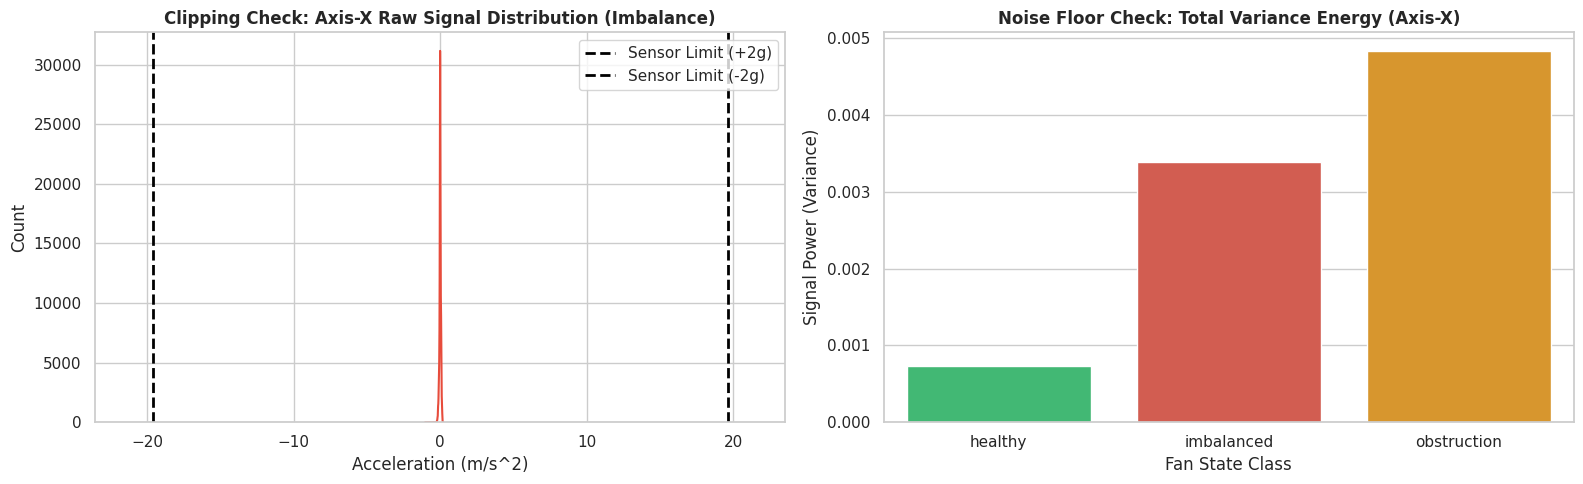

In [ ]:
#@title 4. Clipping and Noise Floor Check:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RAW_DIR = "raw"
MPU6050_LIMIT = 2.0 * 9.81  # Maximum physical scale threshold (+/- 2g)

classes = ["healthy", "imbalanced", "obstruction"]
raw_data = {}

# 1. Load continuous RAW stream dataset from the Acquisition Pipeline
for cls in classes:

    file_path = os.path.join(RAW_DIR, f"arduino_serial_data_{cls}.csv")
    if os.path.exists(file_path):
        raw_data[cls] = pd.read_csv(file_path)
    else:
        print(f"[WARNING] Raw data file not found: {file_path}")

if len(raw_data) == 3:
    print("[OK] All continuous RAW data streams loaded successfully!\n")

    # -----------------------------------------------------
    # STEP 1: SIGNAL CLIPPING DETECTION
    # -----------------------------------------------------
    print("=== 1. SIGNAL CLIPPING & SATURATION CHECK ===")
    clipping_detected = False

    for cls in classes:
        df_raw = raw_data[cls]
        # Evaluate absolute peak acceleration values across all three orthogonal axes
        max_x = np.max(np.abs(df_raw['accX']))
        max_y = np.max(np.abs(df_raw['accY']))
        max_z = np.max(np.abs(df_raw['accZ']))

        print(f"[{cls.upper()}] Peak Amplitude -> X: {max_x:.2f}, Y: {max_y:.2f}, Z: {max_z:.2f} m/s^2")

        # Trigger hardware saturation warning if peaks violate the +/-2g physical constraint
        if max_x >= MPU6050_LIMIT or max_y >= MPU6050_LIMIT or max_z >= MPU6050_LIMIT:
            print(f" -> [WARNING] Signal saturated the physical limit ({MPU6050_LIMIT:.2f} m/s^2). Waveform clipping occurred!")
            clipping_detected = True

    if not clipping_detected:
        print(f" -> [PASS] Signal headroom verified. Max amplitudes are within safe operating limits (< {MPU6050_LIMIT:.2f} m/s^2).\n")

    # -----------------------------------------------------
    # STEP 2: NOISE FLOOR & SIGNAL-TO-NOISE RATIO (SNR) ANALYSIS
    # -----------------------------------------------------
    print("=== 2. NOISE FLOOR EVALUATION & SNR METRICS ===")
    # Utilize variance of Axis-X to represent dynamic signal power
    power_healthy = np.var(raw_data['healthy']['accX'])
    power_imbalance = np.var(raw_data['imbalanced']['accX'])
    power_obstruction = np.var(raw_data['obstruction']['accX'])

    # Calculate Signal-to-Noise Ratio (SNR) in Decibels (dB)
    # The 'healthy' state is defined as the baseline mechanical and sensor noise floor
    snr_imbalance_db = 10 * np.log10(power_imbalance / power_healthy)
    snr_obstruction_db = 10 * np.log10(power_obstruction / power_healthy)

    print(f"Signal Power Variance (Axis-X):")
    print(f" - Healthy State (Baseline Noise Floor): {power_healthy:.4f}")
    print(f" - Imbalance State (Fault Signal Target):  {power_imbalance:.4f} -> SNR = {snr_imbalance_db:.2f} dB")
    print(f" - Obstruction State (Fault Signal Target): {power_obstruction:.4f} -> SNR = {snr_obstruction_db:.2f} dB")

    # Industry Rule of Thumb: SNR > 10dB (major faults) and > 3dB (minor faults) ensures linear separability
    if snr_imbalance_db > 10 and snr_obstruction_db > 3:
        print(" -> [PASS] Fault signal power significantly dominates the noise floor.")
        print("           Linear ML models (e.g., Logistic Regression) will achieve clear separability.\n")
    else:
        print(" -> [WARNING] Fault signature is weak; risk of signal degradation within the noise floor!\n")

    # -----------------------------------------------------
    # STEP 3: DIAGNOSTIC PLOT GENERATION
    # -----------------------------------------------------
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    sns.set_theme(style="whitegrid")

    # Subplot 1: Distribution Density (Histogram) to verify structural clipping/flattened peaks
    sns.histplot(raw_data['imbalanced']['accX'], ax=ax1, color='#e74c3c', kde=True, bins=50)
    ax1.axvline(x=MPU6050_LIMIT, color='black', linestyle='--', linewidth=2, label='Sensor Limit (+2g)')
    ax1.axvline(x=-MPU6050_LIMIT, color='black', linestyle='--', linewidth=2, label='Sensor Limit (-2g)')
    ax1.set_title('Clipping Check: Axis-X Raw Signal Distribution (Imbalance)', fontweight='bold')
    ax1.set_xlabel('Acceleration (m/s^2)')
    ax1.set_xlim(-MPU6050_LIMIT * 1.2, MPU6050_LIMIT * 1.2)
    ax1.legend()

    # Subplot 2: Energy comparison to evaluate statistical margin from the Noise Floor
    energies = [power_healthy, power_imbalance, power_obstruction]
    sns.barplot(x=classes, y=energies, palette=['#2ecc71', '#e74c3c', '#f39c12'], ax=ax2, hue=classes, legend=False)
    ax2.set_title('Noise Floor Check: Total Variance Energy (Axis-X)', fontweight='bold')
    ax2.set_ylabel('Signal Power (Variance)')
    ax2.set_xlabel('Fan State Class')

    plt.tight_layout()
    plt.show()
else:
    print(f"[WARNING] Not all raw data files found. Skipping raw signal analysis.")


--- EMBEDDED RUNTIME SENSOR SCALER PARAMETERS ---
Feature 'RMS_X': Mean = 0.041471, Std = 0.027061
Feature 'RMS_Y': Mean = 0.048831, Std = 0.031614
Feature 'RMS_Z': Mean = 0.109785, Std = 0.047080
Feature 'Band_Power_Z_Low': Mean = 0.000124, Std = 0.000251
Feature 'Band_Power_Z_Mid': Mean = 0.000389, Std = 0.000492
Feature 'Band_Power_Z_High': Mean = 0.000164, Std = 0.000277
------------------------------------------------------------
METERING MODEL PERFORMANCE (TEST DATASET):
              precision    recall  f1-score   support

     healthy       1.00      1.00      1.00        70
  imbalanced       1.00      1.00      1.00        68
 obstruction       1.00      1.00      1.00        55

    accuracy                           1.00       193
   macro avg       1.00      1.00      1.00       193
weighted avg       1.00      1.00      1.00       193



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


<Figure size 800x600 with 0 Axes>

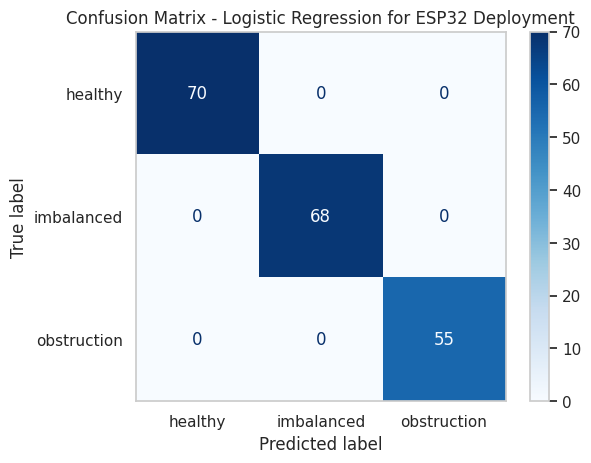

In [ ]:
#@title 6. Logistic Regression:
from sklearn.model_selection import train_test_split

# Re-load the data to ensure we have the latest version
df = pd.read_csv(FILE_PATH)

# Select only the 6 features required for training
features_to_use = ['RMS_X', 'RMS_Y', 'RMS_Z', 'Band_Power_Z_Low', 'Band_Power_Z_Mid', 'Band_Power_Z_High']
X = df[features_to_use]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("--- EMBEDDED RUNTIME SENSOR SCALER PARAMETERS ---")
for i, col in enumerate(X.columns):
    print(f"Feature '{col}': Mean = {scaler.mean_[i]:.6f}, Std = {scaler.scale_[i]:.6f}")
print("-" * 60)

# Logistic Regression Algorithm:
lr_model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train_scaled, y_train)

y_pred = lr_model.predict(X_test_scaled)

print("METERING MODEL PERFORMANCE (TEST DATASET):")
print(classification_report(y_test, y_pred))

# Confusion Matrix Illustration
cm = confusion_matrix(y_test, y_pred, labels=lr_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr_model.classes_)

plt.figure(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix - Logistic Regression for ESP32 Deployment")
plt.grid(False)
plt.show()


In [ ]:
# ==============================================================================
# AUTOMATED C++ HEADER EXPORT (ZERO MANUAL INPUT CONFIGURATION)
# ==============================================================================
# This cell automatically binds both the StandardScaler coefficients and the
# Logistic Regression model weights into a single, unified 'model_parameters.h'.

import numpy as np

# Ensure lr_model and scaler variables match your training pipeline
# lr_model = LogisticRegression(multi_class='ovr', solver='liblinear')
# scaler = StandardScaler()

# 1. Cast parameters safely to 32-bit floats for the ESP32 Hardware FPU
means = scaler.mean_.astype(np.float32)
stds = scaler.scale_.astype(np.float32)
W = lr_model.coef_.astype(np.float32)
b = lr_model.intercept_.astype(np.float32)

n_classes, n_features = W.shape

# 2. Build the C++ header structural framework
cpp_header = """/*
 * model_parameters.h
 * Auto-generated header file for ESP32 edge deployment.
 * Architecture: Logistic Regression (One-vs-Rest)
 * Optimization: Memory-mapped to Flash ROM via 'const' definitions.
 * DO NOT MODIFY THIS FILE MANUALLY.
 */

#ifndef MODEL_PARAMETERS_H
#define MODEL_PARAMETERS_H

#include <stdint.h>

#define MODEL_NUM_CLASSES   {n_classes}
#define MODEL_NUM_FEATURES  {n_features}

// ==============================================================================
// RUNTIME DATA NORMALIZATION (STANDARDSALER OVERHEAD SYNC)
// ==============================================================================
// Math constraint on MCU: x_scaled = (x_raw - MEAN) / STD
const float SCALER_MEAN[MODEL_NUM_FEATURES] = {{ {means_str} }};
const float SCALER_STD[MODEL_NUM_FEATURES]  = {{ {stds_str} }};

// ==============================================================================
// LOGISTIC REGRESSION WEIGHT MATRICES & BIAS VECTORS
// ==============================================================================
// Layout: Row-major matrix representation [Classes][Features]
const float LGR_WEIGHTS[MODEL_NUM_CLASSES][MODEL_NUM_FEATURES] = {{
""".format(
    n_classes=n_classes,
    n_features=n_features,
    means_str=", ".join([f"{m:.6f}f" for m in means]),
    stds_str=", ".join([f"{s:.6f}f" for s in stds])
)

# Append weight arrays with class index tracking references
for idx, class_weights in enumerate(W):
    weights_str = ", ".join([f"{w:.6f}f" for w in class_weights])
    class_label = lr_model.classes_[idx]
    cpp_header += f"    {{ {weights_str} }}, // Class {idx} Target: {class_label}\n"

cpp_header += "};\n\n"

# Append bias vectors
biases_str = ", ".join([f"{bias:.6f}f" for bias in b])
cpp_header += f"const float LGR_BIASES[MODEL_NUM_CLASSES] = {{ {biases_str} }};\n\n"

# Metadata labels for embedded logging interface
cpp_header += "const char* const MODEL_CLASS_LABELS[MODEL_NUM_CLASSES] = {\n"
for class_label in lr_model.classes_:
    cpp_header += f'    "{class_label}",\n'
cpp_header += "};\n"

cpp_header += "\n#endif // MODEL_PARAMETERS_H\n"

# 3. Commit output buffer directly to the local workspace disk
OUTPUT_FILENAME = "model_parameters.h"
with open(OUTPUT_FILENAME, "w") as f:
    f.write(cpp_header)

print(f"[SUCCESS] Generation closed. Dynamic metadata successfully injected into '{OUTPUT_FILENAME}'.")
print(f"-> Verified Constraints: Features={n_features}, Classes={n_classes}")

[SUCCESS] Generation closed. Dynamic metadata successfully injected into 'model_parameters.h'.
-> Verified Constraints: Features=6, Classes=3


In [ ]:
#@title Small Dense NN Declaration:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Re-load the data and select features for neural network training
df = pd.read_csv(FILE_PATH)
features_to_use = ['RMS_X', 'RMS_Y', 'RMS_Z', 'Band_Power_Z_Low', 'Band_Power_Z_Mid', 'Band_Power_Z_High']
X = df[features_to_use]
y = df['label']

# Prepare train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Encode labels to numeric values
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Build the neural network
model = Sequential([
    Dense(16, activation='relu', input_shape=(6,)),
    Dense(8, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 275 (1.07 KB)

 Trainable params: 275 (1.07 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#@title Training Small Dense NN:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train_encoded,
    validation_split=0.2,
    epochs=300,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6585 - loss: 0.9085 - val_accuracy: 0.6753 - val_loss: 0.8335
Epoch 2/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7447 - loss: 0.7224 - val_accuracy: 0.7273 - val_loss: 0.6699
Epoch 3/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7902 - loss: 0.5621 - val_accuracy: 0.7727 - val_loss: 0.5463
Epoch 4/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8228 - loss: 0.4441 - val_accuracy: 0.9026 - val_loss: 0.4502
Epoch 5/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9154 - loss: 0.3480 - val_accuracy: 0.9675 - val_loss: 0.3541
Epoch 6/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9724 - loss: 0.2595 - val_accuracy: 0.9740 - val_loss: 0.2567
Epoch 7/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9837 - loss: 0.1785 - val_accuracy: 0.9870 - val_loss: 0.1712
Epoch 8/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9935 - loss: 0.1194 - val_accuracy: 0.9870 - v

In [ ]:
#@title Evaluation:
test_loss, test_acc = model.evaluate(
    X_test_scaled,
    y_test_encoded,
    verbose=0
)

print(f"Test Accuracy: {test_acc:.4f}")


Test Accuracy: 0.9948


In [ ]:
#@title Prediction Cell Report + Classification Report:
y_pred_prob = model.predict(X_test_scaled)
y_pred_encoded = y_pred_prob.argmax(axis=1)

# Decode predictions and actual labels
y_pred = le.inverse_transform(y_pred_encoded)
y_test_decoded = le.inverse_transform(y_test_encoded)

print(classification_report(y_test_decoded, y_pred))

cm = confusion_matrix(y_test_decoded, y_pred)
print(cm)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
              precision    recall  f1-score   support

     healthy       1.00      1.00      1.00        70
  imbalanced       0.99      1.00      0.99        68
 obstruction       1.00      0.98      0.99        55

    accuracy                           0.99       193
   macro avg       1.00      0.99      0.99       193
weighted avg       0.99      0.99      0.99       193

[[70  0  0]
 [ 0 68  0]
 [ 0  1 54]]


In [ ]:
#@title Extract Small Dense NN Model:
weights = model.get_weights()

for i, w in enumerate(weights):
    print(i, w.shape)

import numpy as np

W1, B1, W2, B2, W3, B3 = model.get_weights()

with open("model_parameters.h", "w") as f:

    f.write("#ifndef MODEL_PARAMETERS_H\n")
    f.write("#define MODEL_PARAMETERS_H\n\n")

    # Scaler
    f.write("const float SCALER_MEAN[6] = {")
    f.write(",".join(f"{x:.8f}" for x in scaler.mean_))
    f.write("};\n\n")

    f.write("const float SCALER_STD[6] = {")
    f.write(",".join(f"{x:.8f}" for x in scaler.scale_))
    f.write("};\n\n")

    # Layer 1
    f.write("const float W1[16][6] = {\n")

    for row in W1.T:
        vals = ",".join(f"{v:.8f}" for v in row)
        f.write("{" + vals + "},\n")

    f.write("};\n\n")

    f.write("const float B1[16] = {")
    f.write(",".join(f"{x:.8f}" for x in B1))
    f.write("};\n\n")

    # Layer 2
    f.write("const float W2[8][16] = {\n")

    for row in W2.T:
        vals = ",".join(f"{v:.8f}" for v in row)
        f.write("{" + vals + "},\n")

    f.write("};\n\n")

    f.write("const float B2[8] = {")
    f.write(",".join(f"{x:.8f}" for x in B2))
    f.write("};\n\n")

    # Output
    f.write("const float W3[3][8] = {\n")

    for row in W3.T:
        vals = ",".join(f"{v:.8f}" for v in row)
        f.write("{" + vals + "},\n")

    f.write("};\n\n")

    f.write("const float B3[3] = {")
    f.write(",".join(f"{x:.8f}" for x in B3))
    f.write("};\n\n")

    # Add label mapping
    f.write("const char* const MODEL_CLASS_LABELS[3] = {\n")
    for label in le.classes_:
        f.write(f'    "{label}",\n')
    f.write("};\n\n")

    f.write("#endif\n")

print("model_parameters.h generated")


0 (6, 16)
1 (16,)
2 (16, 8)
3 (8,)
4 (8, 3)
5 (3,)
model_parameters.h generated
